# Exploratory Data Analysis - Customer Behavior & Business Performance Analysis

The purpose of this notebook is to perform **Exploratory Data Analysis (EDA)** on a simulated e‑commerce dataset in order to understand **customer behavior, browsing patterns, purchase behavior, and product performance**.  

By analyzing session activity, page depth, and conversion outcomes, this notebook aims to:
- Identify typical browsing patterns and engagement levels.  
- Explore how session duration and pages viewed influence conversion.  
- Examine purchasing behavior to uncover signals of intent.  
- Assess product performance to highlight best‑sellers and underperformers.  

The insights generated will provide a **data‑driven foundation** for improving customer experience, optimizing navigation, and guiding business strategies that enhance conversion and product engagement.



In [63]:
#importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## Dataset Overview

The analysis is based on a simulated e-commerce dataset consisting of multiple tables:

- **customers** → Customer details and acquisition information
- **sessions** → User activity and engagement behavior
- **cart** → Add-to-cart interactions
- **orders** → Completed transactions (revenue and margin)
- **products** → Product details and category information

These tables collectively represent the full customer journey from session to purchase.

In [64]:
customers = pd.read_csv('../data/raw/customers.csv')
sessions = pd.read_csv('../data/raw/sessions.csv')
cart = pd.read_csv('../data/raw/cart_events.csv')
orders = pd.read_csv('../data/raw/orders.csv')
products = pd.read_csv('../data/raw/products.csv')

# Data Validation and Quality Checks

This section summarizes:
- Data types of each column  
- Missing values  
- Unique values  
- Shape of the dataset  
- Duplicate records  

The following validation is performed for: **Customers, Sessions, Cart, Orders, and Products**.

In [65]:
def validate(df, name):
    print(f"\n📊 {name}")
    summary = pd.DataFrame({
        "Data Type": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique()
    })
    print(summary)
    print("Shape:", df.shape)
    print("Duplicates:", df.duplicated().sum())


#validating each dataframe
validate(customers, "Customers")
validate(sessions, "Sessions")
validate(cart, "Cart")
validate(orders, "Orders")
validate(products, "Products")


📊 Customers
                    Data Type  Missing Values  Unique Values
customer_id             int64               0           2500
acquisition_channel    object               0              4
signup_date            object               0            184
ab_group               object               0              2
Shape: (2500, 4)
Duplicates: 0

📊 Sessions
                 Data Type  Missing Values  Unique Values
session_id           int64               0          12474
customer_id          int64               0           2492
session_date        object               0            184
device              object               0              3
traffic_source      object               0              4
pages_viewed         int64               0             11
session_duration     int64               0            870
bounced_flag         int64               0              2
Shape: (12474, 8)
Duplicates: 0

📊 Cart
                Data Type  Missing Values  Unique Values
cart_id             

## Data Cleaning: Key Fixes

- **Customers:** `signup_date` → converted from string to `datetime`.  
- **Sessions:** `session_date` → `datetime`; `session_duration` → `timedelta`; `bounced_flag` → `category`.  
- **Cart:** `event_timestamp` → `datetime`.  
- **Orders:** `order_date` → `datetime`; `ab_group` → `category`.  


In [66]:


# --- Customers table ---
# Convert signup_date from object (string) to datetime
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

# --- Sessions table ---
# Convert session_date from object to datetime and session_duration from seconds (int) to timedelta
sessions['session_date'] = pd.to_datetime(sessions['session_date'])
sessions['session_duration'] = pd.to_timedelta(sessions['session_duration'], unit='s')
sessions['bounced_flag'] = sessions['bounced_flag'].astype('category')

# --- Cart table ---
# Convert event_timestamp from object to datetime
cart['event_timestamp'] = pd.to_datetime(cart['event_timestamp'])

# --- Orders table ---
# Convert order_date from object to datetime
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['ab_group'] = orders['ab_group'].astype('category')

# --- Products table ---
# Converting categorical columns to category dtype for memory efficiency
products['category'] = products['category'].astype('category')

All datatypes across the datasets have been successfully cleaned and standardized, ensuring consistency for accurate KPI calculations and analysis.

# 📊 Key Performance Indicators (KPIs)

### KPI Definitions 

| KPI Name              | Formula                                | Description |
|-----------------------|----------------------------------------|-------------|
| Total Users           | Count of unique customer_id            | Total number of distinct customers/users on the platform |
| Total Sessions        | Count of session_id                    | Total number of visits or browsing sessions |
| Total Orders          | Count of order_id                      | Total number of completed purchase transactions |
| Total Revenue         | Sum(order_value)                       | Total monetary value of all completed orders |
| Conversion Rate       | (Total Orders ÷ Total Sessions) × 100  | Percentage of sessions that result in a purchase |
| Add-to-Cart Rate      | (Cart Events ÷ Total Sessions) × 100   | Percentage of sessions where at least one item is added to cart |
| Cart Abandonment Rate | ((Cart Events − Orders) ÷ Cart Events) × 100 | Percentage of carts created that did not convert into orders |
| Average Order Value   | (Total Revenue ÷ Total Orders)         | Average revenue generated per order |
| Orders per Customer   | (Total Orders ÷ Total Users)           | Average number of orders placed per customer |


In [67]:
total_users = customers['customer_id'].nunique()
total_sessions = sessions['session_id'].nunique()
total_orders = orders['order_id'].nunique()

orders['revenue'] = orders['final_price'] * orders['quantity']
total_revenue = orders['revenue'].sum()
total_margin = orders['margin'].sum()

conversion_rate = total_orders / total_sessions

total_cart = cart['cart_id'].nunique()
add_to_cart_rate = total_cart / total_sessions
cart_abandonment_rate = (total_cart - total_orders) / total_cart

average_order_value = total_revenue / total_orders
orders_per_customer = total_orders / total_users

# --- Print Results ---
print("Total Users:", total_users)
print("Total Sessions:", total_sessions)
print("Total Orders:", total_orders)
print("Total Revenue:", round(total_revenue, 2))
print("Conversion Rate:", round(conversion_rate * 100, 2), "%")
print("Add-to-Cart Rate:", round(add_to_cart_rate * 100, 2), "%")
print("Cart Abandonment Rate:", round(cart_abandonment_rate * 100 , 2), "%")
print("Average Order Value:", round(average_order_value, 2))
print("Orders per Customer:", round(orders_per_customer, 2))


Total Users: 2500
Total Sessions: 12474
Total Orders: 1186
Total Revenue: 34973492.65
Conversion Rate: 9.51 %
Add-to-Cart Rate: 41.6 %
Cart Abandonment Rate: 77.14 %
Average Order Value: 29488.61
Orders per Customer: 0.47


# 📊 KPI Insights

- 👥 Users & Sessions: 2,500 users, 12,474 sessions (~5 per user).Good engagement at the top of the funnel. Focus on scaling user acquisition to grow further.

- 🛒 Conversion Rate: 9.51% - Strong compared to industry average (2–5%). Maintain by continuing to attract high‑intent customers.

- 🛒 Add-to-Cart Rate: 41.6% - Very high intent, customers actively explore products. Improve by nudging more carts toward checkout with offers or reminders.

- 🛒 Cart Abandonment: 77.1% - High leakage, aligned with industry norms but costly. Reduce checkout friction, transparent pricing, and recovery campaigns.

- 💰 Revenue: ₹34.9M from 1,186 orders | AOV: ₹29.4K - Excellent revenue per order, premium/high-ticket products dominate. Leverage with upselling, bundles, and cross‑selling to maximize value.

- 🔄 Orders per Customer: 0.47 - Weak retention, most customers buy only once. Can be improved by loyalty programs, personalized offers, and re‑engagement strategies.


# 📊 Daily Revenue Trends

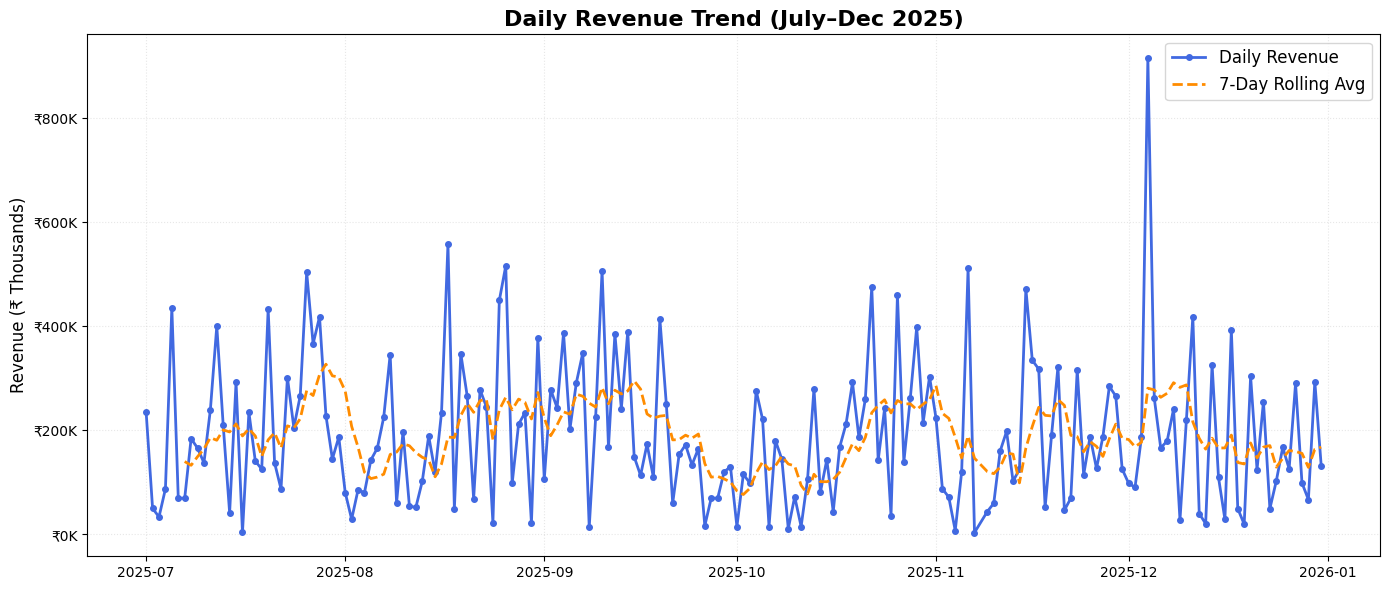

In [77]:
import matplotlib.ticker as mtick

# Group daily revenue
daily_revenue = orders.groupby('order_date')['revenue'].sum()

# Create figure
plt.figure(figsize=(14,6))
plt.plot(daily_revenue.index, daily_revenue.values, 
         color='royalblue', linewidth=2, marker='o', markersize=4, 
         label='Daily Revenue')

# Add rolling average for trend smoothing
rolling_avg = daily_revenue.rolling(window=7).mean()
plt.plot(rolling_avg.index, rolling_avg.values, 
         color='darkorange', linewidth=2, linestyle='--', 
         label='7-Day Rolling Avg')

# Titles and labels
plt.title('Daily Revenue Trend (July–Dec 2025)', fontsize=16, fontweight='bold')
plt.ylabel('Revenue (₹ Thousands)', fontsize=12)

# Format y-axis in thousands
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'₹{x/1e3:.0f}K')
)

# Grid, legend, and style
plt.grid(alpha=0.3, linestyle=':')
plt.legend(fontsize=12)
plt.tight_layout()

# Show plot
plt.show()


- 📈 Seasonal Peaks: Noticeable revenue spike in early December, likely driven by festive shopping and year‑end promotions. Smaller peaks are visible in late July and September, reflecting periodic campaigns or seasonal demand.  

- 📊 Volatility: Daily revenue fluctuates sharply, with several short‑term drops and rebounds. The 7‑day rolling average smooths these movements, showing a more stable upward trend leading into December.  

- 💼 Business Impact: Revenue is highly influenced by festive and promotional periods. Aligning inventory, logistics, and marketing campaigns with these spikes is essential to capture maximum value and reduce missed opportunities during high‑demand phases.  


# 📊 Revenue Contribution by Product Category

C:\Users\hp\AppData\Local\Temp\ipykernel_19420\898721044.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orders_products.groupby('category')['revenue']


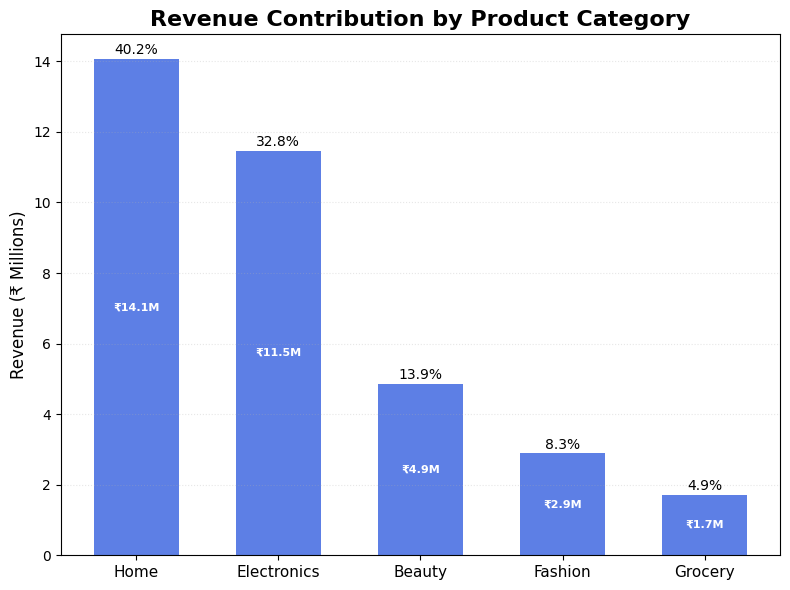

In [81]:
import matplotlib.pyplot as plt

# Merge orders with products
orders_products = orders.merge(products, on='product_id', how='left')

# Revenue by category 
category_revenue = (
    orders_products.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False) / 1_000_000
)

# Plot bars
plt.figure(figsize=(8,6))
bars = plt.bar(category_revenue.index, category_revenue.values,
               color='royalblue', alpha=0.85, width=0.6)  # reduced width

# Add value labels (₹ Millions) inside bars
for bar, value in zip(bars, category_revenue.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
             f"₹{value:.1f}M",
             ha='center', va='center', color='white', fontsize=8, fontweight='bold')

# Add % contribution labels above bars
total_revenue = category_revenue.sum()
for bar, value in zip(bars, category_revenue.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.05,
             f"{(value/total_revenue)*100:.1f}%",
             ha='center', va='bottom', color='black', fontsize=10)

# Titles and labels
plt.title('Revenue Contribution by Product Category', fontsize=16, fontweight='bold')
plt.ylabel('Revenue (₹ Millions)', fontsize=12)

# Styling
plt.xticks(rotation=0, fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle=':')
plt.tight_layout()
plt.show()


- 📈 Category Leaders: Home contributes ₹14.1M (40.2%) and Electronics ₹11.5M (32.8%), together accounting for nearly three‑quarters of total revenue.  

- 📊 Secondary Categories: Beauty ₹4.9M (13.9%) and Fashion ₹2.9M (8.3%) provide moderate contributions, while Grocery ₹1.7M (4.9%) remains the smallest segment.  

- 💼 Business Impact: Revenue is concentrated in Home and Electronics. Diversifying into Beauty, Fashion, and Grocery is critical to reduce dependency and unlock balanced growth opportunities.  


# 📊 Revenue vs Margin by Product Category

C:\Users\hp\AppData\Local\Temp\ipykernel_19420\1291583956.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orders_products.groupby('category')[['revenue', 'margin']]


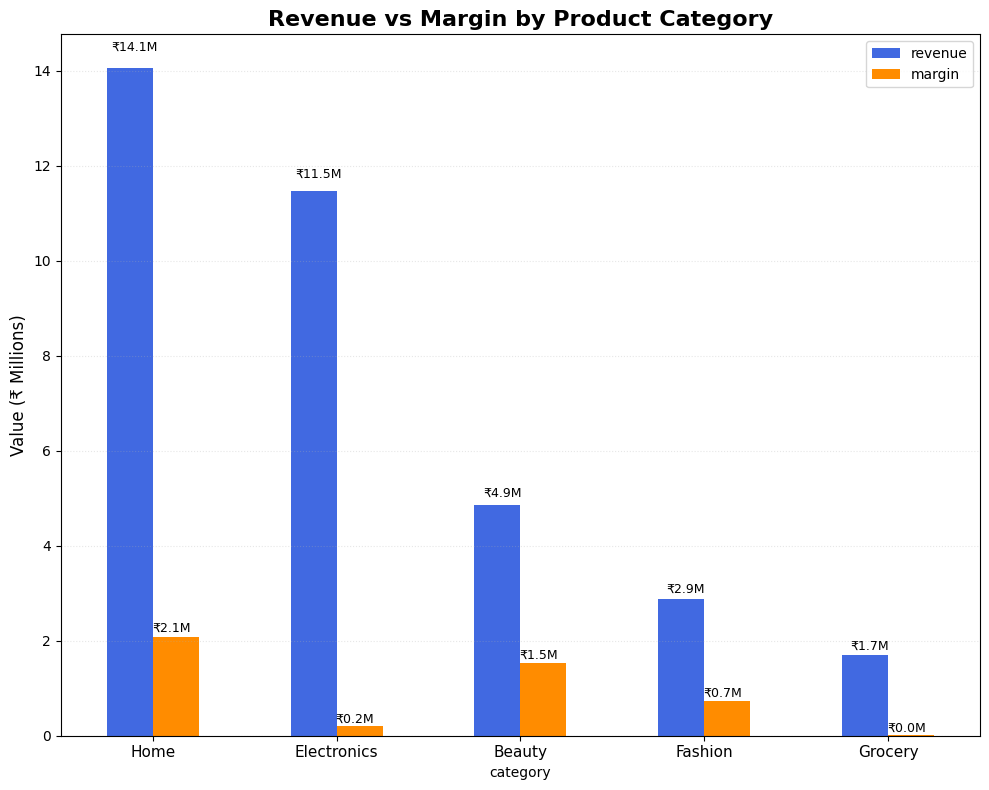

In [83]:

# Merge orders with products
orders_products = orders.merge(products, on='product_id', how='left')

# Aggregate revenue and margin by category
category_summary = (
    orders_products.groupby('category')[['revenue', 'margin']]
    .sum()
    .sort_values(by='revenue', ascending=False)
)

# Convert to millions
category_summary_m = category_summary / 1_000_000

# Plot
ax = category_summary_m.plot(kind='bar', figsize=(10,8), color=['royalblue','darkorange'])

# Add value labels
for idx, (rev, mar) in enumerate(zip(category_summary['revenue'], category_summary['margin'])):
    ax.text(idx-0.10, rev/1_000_000 + (rev/1_000_000)*0.02, f"₹{rev/1_000_000:.1f}M",
            ha='center', va='bottom', fontsize=9, color='black')
    ax.text(idx+0.10, mar/1_000_000 + (mar/1_000_000)*0.02, f"₹{mar/1_000_000:.1f}M",
            ha='center', va='bottom', fontsize=9, color='black')


# Titles and labels
plt.title('Revenue vs Margin by Product Category', fontsize=16, fontweight='bold')
plt.ylabel('Value (₹ Millions)', fontsize=12)

# Styling
plt.xticks(rotation=0, fontsize=11)  # horizontal labels
plt.grid(axis='y', alpha=0.3, linestyle=':')
plt.tight_layout()

plt.show()

- 📈 Home delivers the highest revenue at ₹14.1M with a margin of ₹2.1M, showing strong profitability. Electronics follows with ₹11.5M revenue but only ₹0.2M margin, highlighting razor‑thin profitability despite large sales.  

- 📊 Beauty contributes ₹4.9M revenue with a healthy ₹1.5M margin, while Fashion adds ₹2.9M revenue and ₹0.7M margin. Grocery remains the weakest, at ₹1.7M revenue and negligible margin.  

- 💼 Business Impact: Revenue is concentrated in Home and Electronics, but Electronics’ margins are unsustainably low. Beauty and Fashion, though smaller in revenue, generate stronger margins relative to their size. Strategic focus should be on improving Electronics’ profitability and scaling Beauty/Fashion to balance growth and margin contribution.  



# 📊 Distribution of order value


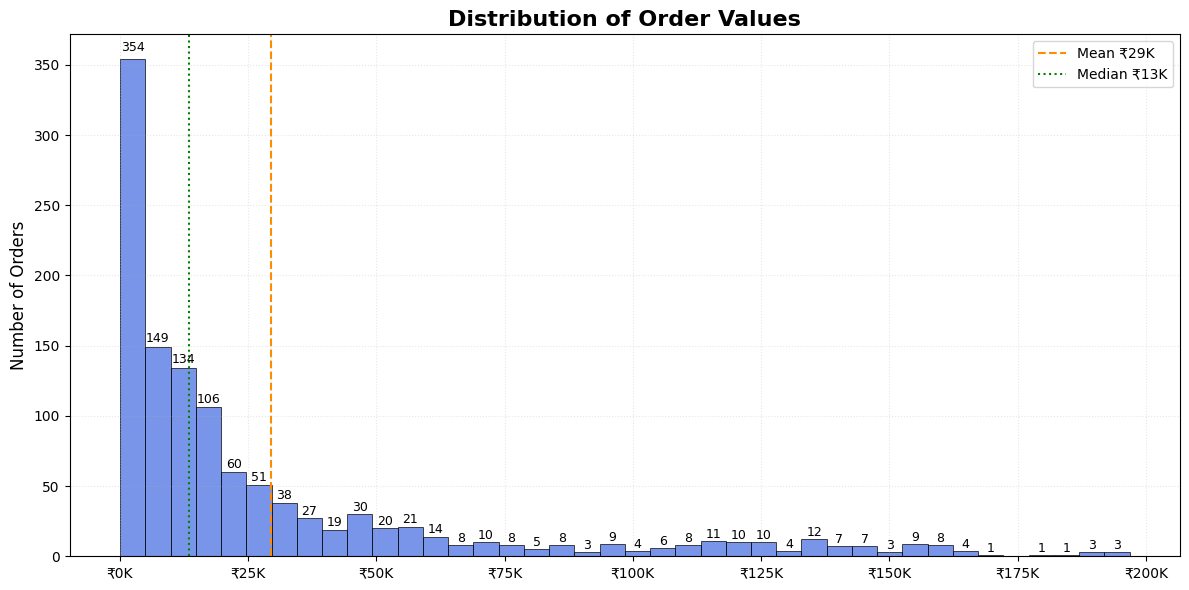

In [89]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Convert to thousands
order_value_k = orders['revenue'] / 1_000

plt.figure(figsize=(12,6))

# Histogram with borders
counts, bins, patches = plt.hist(order_value_k, bins=40,
                                 color='royalblue', alpha=0.7,
                                 edgecolor='black', linewidth=0.7)

# Add labels on top of bars with proportional offset
bin_width = bins[1] - bins[0]
for count, x in zip(counts, bins[:-1]):
    if count > 0:
        plt.text(x + bin_width/2, count + count*0.01, str(int(count)),
                 ha='center', va='bottom', fontsize=9, color='black')

# Add mean and median lines
mean_val = order_value_k.mean()
median_val = order_value_k.median()
plt.axvline(mean_val, color='darkorange', linestyle='--', linewidth=1.5, label=f'Mean ₹{mean_val:.0f}K')
plt.axvline(median_val, color='green', linestyle=':', linewidth=1.5, label=f'Median ₹{median_val:.0f}K')

# Titles and labels
plt.title('Distribution of Order Values', fontsize=16, fontweight='bold')
plt.ylabel('Number of Orders', fontsize=12)

# Format x-axis in ₹K
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{x:.0f}K'))

# Styling
plt.grid(alpha=0.3, linestyle=':')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


- 📈 Order Value Spread: Most orders cluster in the lower ranges (₹10K–₹50K), showing that customers tend to purchase mid‑ticket items rather than very high‑value products.  

- 📊 The histogram is right‑skewed — a few very large orders (₹100K+) exist, but they are rare compared to the bulk of smaller transactions.  

- 📉 The mean order value is higher than the median, confirming that outliers (big‑ticket purchases) are pulling the average upward.  

- 💼 Business Impact: Revenue is driven by a small number of high‑value orders, but overall volume comes from mid‑range purchases. Strategies should balance both — nurture premium buyers while encouraging repeat purchases in the mid‑range to stabilize growth.  


# 📊 Session Duration Distribution

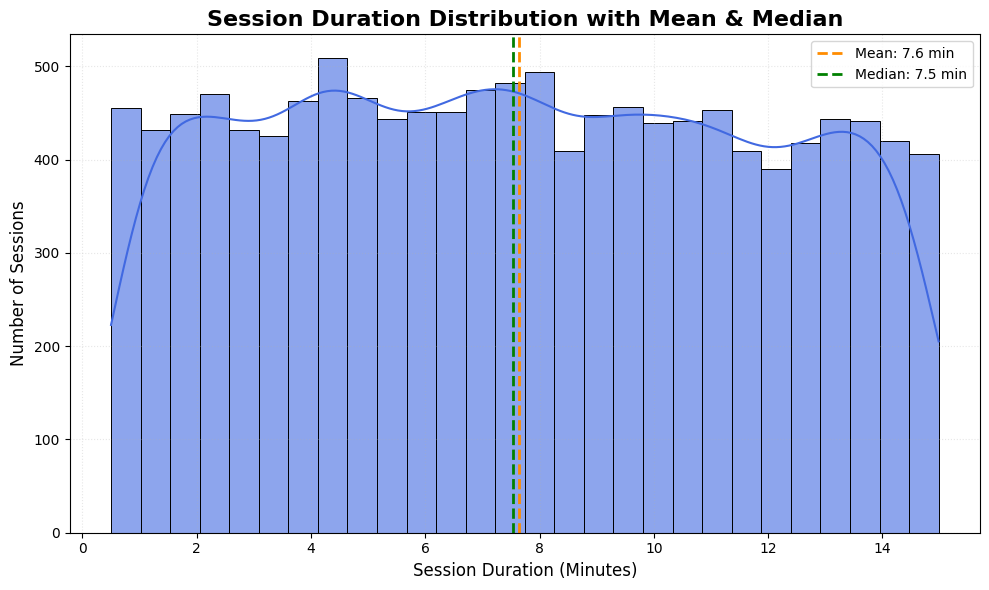

In [92]:

# Convert to minutes
session_duration_min = sessions['session_duration'].dt.total_seconds() / 60

plt.figure(figsize=(10,6))

# Histogram + KDE
sns.histplot(session_duration_min, bins=28,
             color='royalblue', edgecolor='black', linewidth=0.7,
             alpha=0.6, kde=True)

# Mean and Median
mean_val = np.mean(session_duration_min)
median_val = np.median(session_duration_min)

plt.axvline(mean_val, color='darkorange', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f} min')
plt.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f} min')

# Titles and labels
plt.title('Session Duration Distribution with Mean & Median', fontsize=16, fontweight='bold')
plt.xlabel('Session Duration (Minutes)', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

plt.legend()
plt.grid(alpha=0.3, linestyle=':')
plt.tight_layout()
plt.show()

- 📈 Engagement Levels: Most sessions fall between 1–15 minutes, with the mean at 7.6 minutes and median at 7.5 minutes. This indicates a fairly balanced distribution of short and medium‑length sessions.  

- 📊 The histogram is relatively uniform, suggesting consistent engagement across different session lengths rather than sharp peaks or drop‑offs.  

- 📉 The closeness of mean and median shows that session durations are not heavily skewed — outliers (very long or very short sessions) have minimal impact on overall averages.  

- 💼 Business Impact: Users are spending a steady amount of time per session, which reflects healthy engagement. To increase value, strategies could focus on nudging users toward slightly longer sessions (e.g., personalized recommendations, interactive features) to deepen interaction and improve conversion potential.  


# 📊 Pages Viewed per session

C:\Users\hp\AppData\Local\Temp\ipykernel_19420\376785118.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


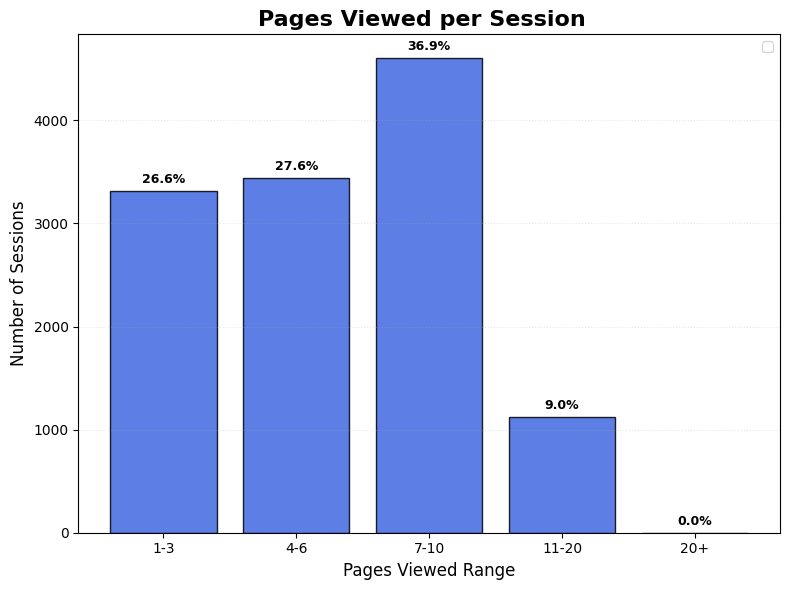

In [93]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define fixed bins and labels
bins = [0, 3, 6, 10, 20, float('inf')]
labels = ['1-3', '4-6', '7-10', '11-20', '20+']

bucketed = pd.cut(sessions['pages_viewed'], bins=bins, labels=labels, right=True)
bucket_counts = bucketed.value_counts().sort_index()

# Mean & Median
mean_val = sessions['pages_viewed'].mean()
median_val = sessions['pages_viewed'].median()

# Plot
plt.figure(figsize=(8,6))
bars = plt.bar(bucket_counts.index, bucket_counts.values,
               color='royalblue', edgecolor='black', alpha=0.85)

# Add percentage labels above bars
total = bucket_counts.sum()
for bar, value in zip(bars, bucket_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+50,
             f"{value/total*100:.1f}%", ha='center', va='bottom',
             fontsize=9, fontweight='bold')


plt.title('Pages Viewed per Session  ', fontsize=16, fontweight='bold')
plt.xlabel('Pages Viewed Range', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3, linestyle=':')
plt.tight_layout()
plt.show()


 - 📈 Engagement Levels: The largest share of sessions (36.9%) fall in the **7–10 pages range**, showing strong mid‑depth browsing behavior.  

- 📊 Short Sessions: About 26.6% of sessions are limited to **1–3 pages**, indicating a sizable group of quick visitors who exit early.  

- 📊 Moderate Sessions: Another 27.6% of sessions fall in the **4–6 pages range**, suggesting a healthy segment of users exploring beyond the first few pages.  

- 📉 Long Sessions: Only 9.0% of sessions extend to **11–20 pages**, and virtually none cross **20+ pages**, highlighting limited ultra‑engaged users.  

- 💼 Business Impact: Engagement is strongest in the mid‑range (4–10 pages), which is promising for conversions. The challenge is to **shift more users from 1–3 pages into the 7–10+ range** through better navigation, personalized recommendations, and content linking.  



# 📊 Conversion Rate 

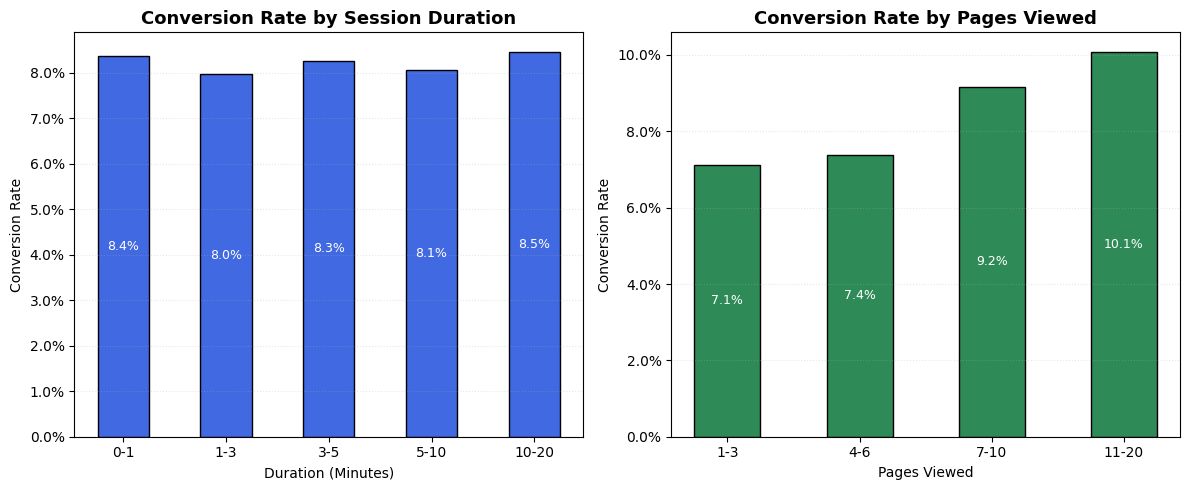

In [105]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- Prep: Create conversion flag ---
sessions['converted'] = sessions['session_id'].isin(orders['session_id']).astype(int)

# --- Convert session_duration to minutes (numeric) ---
sessions['session_duration_min'] = sessions['session_duration'].dt.total_seconds() / 60

# --- Bin session duration ---
sessions['duration_bin'] = pd.cut(
    sessions['session_duration_min'],
    bins=[0, 1, 3, 5, 10, 20, float('inf')],
    labels=['0-1', '1-3', '3-5', '5-10', '10-20', '20+']
)

# --- Bin pages viewed ---
sessions['pages_bin'] = pd.cut(
    sessions['pages_viewed'],
    bins=[0, 3, 6, 10, 20, float('inf')],
    labels=['1-3', '4-6', '7-10', '11-20', '20+']
)

# --- Conversion rates ---
conversion_by_duration = sessions.groupby('duration_bin', observed=True)['converted'].mean()
conversion_by_pages = sessions.groupby('pages_bin', observed=True)['converted'].mean()

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Conversion by Duration
bars1 = axes[0].bar(conversion_by_duration.index.astype(str),
                    conversion_by_duration.values,
                    width=0.5, color='royalblue', edgecolor='black')
for bar, val in zip(bars1, conversion_by_duration.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val/2,
                 f"{val:.1%}", ha='center', va='center', fontsize=9, color='white')
axes[0].set_title('Conversion Rate by Session Duration', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Duration (Minutes)')
axes[0].set_ylabel('Conversion Rate')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0].grid(axis='y', alpha=0.3, linestyle=':')

# Conversion by Pages Viewed
bars2 = axes[1].bar(conversion_by_pages.index.astype(str),
                    conversion_by_pages.values,
                    width=0.5, color='seagreen', edgecolor='black')
for bar, val in zip(bars2, conversion_by_pages.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val/2,
                 f"{val:.1%}", ha='center', va='center', fontsize=9, color='white')
axes[1].set_title('Conversion Rate by Pages Viewed', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pages Viewed')
axes[1].set_ylabel('Conversion Rate')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].grid(axis='y', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()




## 🕒 By Session Duration
- Conversion rates remain **flat across short and medium sessions** (8.0–8.5%).
- Longer time on site does **not automatically increase conversions**.
- Key takeaway: **time alone isn’t the driver** — engagement quality matters more.

## 📄 By Pages Viewed
- Clear upward trend with page depth:
  - **1–3 pages:** 7.1%
  - **4–6 pages:** 7.4%
  - **7–10 pages:** 9.2%
  - **11–20 pages:** 10.1%
- Once users cross ~7 pages, conversion likelihood rises sharply.
- Key takeaway: **exploration depth is the real lever** for boosting conversions.

## 💡 Strategic Implications
- Focus on **nudging users to explore more pages** rather than just keeping them longer.
- Use **personalized recommendations, related products, and smart navigation** to push users past the 7+ page threshold.
- Conversion is powered by **curiosity and exploration**, not clock time.
